# Đánh giá Hiệu năng Tokenizer trên Tập Dữ liệu Tóm tắt (Tokenizer Evaluation Notebook)

Notebook này được thiết kế để chạy trên **Kaggle** (hoặc môi trường Jupyter Notebook cục bộ) để phân tích chi tiết hiệu suất mã hóa của mô hình **SentencePiece Tokenizer**.

### Các chỉ số được đánh giá bao gồm:
1. **Tỷ lệ Token không xác định (UNK Rate)**: Đo lường mức độ bao phủ của bộ từ điển đối với ngữ liệu. Tỷ lệ `<unk>` quá cao cho thấy bộ từ vựng chưa bao phủ tốt ngôn ngữ thực tế.
2. **Độ dài Token của Văn bản gốc (Source Token Length - Contents)**: Phân tích phân phối độ dài (Mean, Median, 75%, 90%, 95%) để cấu hình độ dài tối đa (max sequence length) cho Transformer Encoder.
3. **Độ dài Token của Bản tóm tắt (Target Token Length - Summary)**: Phân tích phân phối độ dài (Mean, Median, 75%, 90%, 95%) để cấu hình độ dài tối đa cho Transformer Decoder.
4. **Tỷ lệ mã hóa (Fertility Rate)**: Tỷ lệ giữa số lượng Token sinh ra sau khi mã hóa và số từ gốc (`len(tokens) / len(words)`). Đánh giá xem từ vựng có bị cắt quá vụn (FR cao) hay bị overfitting (FR gần 1.0). Chúng ta sẽ tính Mean, Median, và 95% percentile cho Fertility Rate.

In [1]:
# Cài đặt thư viện sentencepiece nếu môi trường chưa có
!pip install -q sentencepiece

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sentencepiece as spm

# Cấu hình phong cách đồ họa
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Cấu hình Đường dẫn Dữ liệu & Model

**Lưu ý**: Hãy nhập đường dẫn thực tế của file corpus và file model SentencePiece trên môi trường Kaggle của bạn vào các biến dưới đây.

In [2]:
# HÃY ĐIỀN ĐƯỜNG DẪN THỰC TẾ TRÊN KAGGLE Ở ĐÂY
CORPUS_PATH = "/kaggle/input/notebooks/tranducthinh2006/train-tokenizer/data/processed/tokenizer/tokenizer_corpus.txt"
MODEL_PATH = "/kaggle/input/notebooks/tranducthinh2006/train-tokenizer/data/tokenizer/vietnamese_spm.model"

# Ví dụ đường dẫn trên Kaggle:
# CORPUS_PATH = "/kaggle/input/vietnamese-summarization-corpus/tokenizer_corpus.txt"
# MODEL_PATH = "/kaggle/input/vietnamese-summarization-model/vietnamese_spm.model"

# Tự động kiểm tra nếu để trống thì thử tìm đường dẫn cục bộ (Local)
if not CORPUS_PATH:
    local_corpus = "../data/tokenizer/corpus/tokenizer_corpus.txt"
    if os.path.exists(local_corpus):
        CORPUS_PATH = local_corpus
        print(f"Tự động sử dụng đường dẫn Corpus cục bộ: {CORPUS_PATH}")
    else:
        print("CẢNH BÁO: CORPUS_PATH đang để trống. Hãy điền đường dẫn trước khi chạy tiếp.")

if not MODEL_PATH:
    local_model = "../data/tokenizer/model/vietnamese_spm.model"
    if os.path.exists(local_model):
        MODEL_PATH = local_model
        print(f"Tự động sử dụng đường dẫn Model cục bộ: {MODEL_PATH}")
    else:
        print("CẢNH BÁO: MODEL_PATH đang để trống. Hãy điền đường dẫn trước khi chạy tiếp.")

## 2. Đọc dữ liệu từ file Corpus

Đọc file corpus và tiến hành ghép cặp (Contents - Văn bản gốc, Summary - Tóm tắt). Dữ liệu trong file `tokenizer_corpus.txt` được lưu theo dạng xen kẽ:
- Dòng 1: Contents của mẫu 1
- Dòng 2: Summary của mẫu 1
- Dòng 3: Contents của mẫu 2
- Dòng 4: Summary của mẫu 2
...

In [3]:
if CORPUS_PATH and os.path.exists(CORPUS_PATH):
    print(f"Đang đọc dữ liệu từ file: {CORPUS_PATH}")
    with open(CORPUS_PATH, "r", encoding="utf-8") as f:
        # Loại bỏ các dòng trống hoặc chỉ chứa khoảng trắng để đảm bảo sạch dữ liệu
        lines = [line.strip() for line in f if line.strip()]
    
    # Kiểm tra số lượng dòng
    if len(lines) % 2 != 0:
        print(f"Cảnh báo: Số lượng dòng không trống ({len(lines)}) là số lẻ. Dòng cuối cùng sẽ bị bỏ qua để ghép cặp hoàn chỉnh.")
        lines = lines[:-1]
        
    pairs = []
    for i in range(0, len(lines), 2):
        pairs.append({
            "source": lines[i],
            "target": lines[i+1]
        })
    print(f"-> Đã tải thành công {len(pairs)} cặp (Contents, Summary) từ corpus.")
else:
    print("Vui lòng điền đúng CORPUS_PATH và đảm bảo file tồn tại để tiếp tục.")

Đang đọc dữ liệu từ file: /kaggle/input/notebooks/tranducthinh2006/train-tokenizer/data/processed/tokenizer/tokenizer_corpus.txt
-> Đã tải thành công 197580 cặp (Contents, Summary) từ corpus.


## 3. Tokenize và Thu thập Thống kê

Nạp mô hình SentencePiece và tiến hành mã hóa toàn bộ dữ liệu nhằm tính toán các chỉ số thống kê.

In [4]:
if MODEL_PATH and os.path.exists(MODEL_PATH) and 'pairs' in locals():
    print(f"Đang nạp mô hình SentencePiece từ: {MODEL_PATH}")
    sp = spm.SentencePieceProcessor(model_file=MODEL_PATH)
    unk_id = sp.unk_id()
    print(f"Mô hình đã được nạp thành công! ID của token <unk>: {unk_id}")
    
    # Chuẩn bị các danh sách lưu trữ kết quả thống kê
    source_token_lens = []
    target_token_lens = []
    
    source_word_lens = []
    target_word_lens = []
    
    source_fertilities = []
    target_fertilities = []
    overall_fertilities = []
    
    total_unk_tokens = 0
    total_tokens = 0
    
    # Tiến hành tokenize toàn bộ corpus
    print("Đang xử lý tokenize và tính toán trên toàn bộ dữ liệu...")
    for idx, pair in enumerate(pairs):
        src = pair["source"]
        tgt = pair["target"]
        
        # Đếm số từ khoảng trắng gốc
        src_words = len(src.split())
        tgt_words = len(tgt.split())
        
        # Tokenize sang dạng danh sách ID
        src_ids = sp.encode_as_ids(src)
        tgt_ids = sp.encode_as_ids(tgt)
        
        src_tokens = len(src_ids)
        tgt_tokens = len(tgt_ids)
        
        # Lưu trữ độ dài
        source_token_lens.append(src_tokens)
        target_token_lens.append(tgt_tokens)
        source_word_lens.append(src_words)
        target_word_lens.append(tgt_words)
        
        # Tính Fertility Rate (Tỷ lệ mã hóa) cho mẫu hiện tại
        src_fert = src_tokens / src_words if src_words > 0 else 0.0
        tgt_fert = tgt_tokens / tgt_words if tgt_words > 0 else 0.0
        overall_fert = (src_tokens + tgt_tokens) / (src_words + tgt_words) if (src_words + tgt_words) > 0 else 0.0
        
        source_fertilities.append(src_fert)
        target_fertilities.append(tgt_fert)
        overall_fertilities.append(overall_fert)
        
        # Thống kê UNK tokens
        src_unks = src_ids.count(unk_id)
        tgt_unks = tgt_ids.count(unk_id)
        
        total_unk_tokens += (src_unks + tgt_unks)
        total_tokens += (src_tokens + tgt_tokens)
        
        # In tiến trình mỗi 10,000 mẫu
        if (idx + 1) % 10000 == 0:
            print(f"  - Đã xử lý xong {idx + 1}/{len(pairs)} mẫu...")
            
    print("Hoàn thành quá trình tokenize!")
else:
    print("Vui lòng nạp thành công Model và Corpus ở các bước trước.")

Đang nạp mô hình SentencePiece từ: /kaggle/input/notebooks/tranducthinh2006/train-tokenizer/data/tokenizer/vietnamese_spm.model
Mô hình đã được nạp thành công! ID của token <unk>: 1
Đang xử lý tokenize và tính toán trên toàn bộ dữ liệu...
  - Đã xử lý xong 10000/197580 mẫu...
  - Đã xử lý xong 20000/197580 mẫu...
  - Đã xử lý xong 30000/197580 mẫu...
  - Đã xử lý xong 40000/197580 mẫu...
  - Đã xử lý xong 50000/197580 mẫu...
  - Đã xử lý xong 60000/197580 mẫu...
  - Đã xử lý xong 70000/197580 mẫu...
  - Đã xử lý xong 80000/197580 mẫu...
  - Đã xử lý xong 90000/197580 mẫu...
  - Đã xử lý xong 100000/197580 mẫu...
  - Đã xử lý xong 110000/197580 mẫu...
  - Đã xử lý xong 120000/197580 mẫu...
  - Đã xử lý xong 130000/197580 mẫu...
  - Đã xử lý xong 140000/197580 mẫu...
  - Đã xử lý xong 150000/197580 mẫu...
  - Đã xử lý xong 160000/197580 mẫu...
  - Đã xử lý xong 170000/197580 mẫu...
  - Đã xử lý xong 180000/197580 mẫu...
  - Đã xử lý xong 190000/197580 mẫu...
Hoàn thành quá trình tokenize

## 4. Tính toán và Hiển thị Kết quả Thống kê

Tính toán các phân vị chi tiết theo yêu cầu của đề bài.

In [5]:
if 'total_tokens' in locals() and total_tokens > 0:
    # 1. Tính toán UNK Rate
    unk_rate = (total_unk_tokens / total_tokens) * 100
    
    # 2. Tính các phân vị cho Source Token Length
    src_mean = np.mean(source_token_lens)
    src_median = np.median(source_token_lens)
    src_p75 = np.percentile(source_token_lens, 75)
    src_p90 = np.percentile(source_token_lens, 90)
    src_p95 = np.percentile(source_token_lens, 95)
    
    # 3. Tính các phân vị cho Target Token Length
    tgt_mean = np.mean(target_token_lens)
    tgt_median = np.median(target_token_lens)
    tgt_p75 = np.percentile(target_token_lens, 75)
    tgt_p90 = np.percentile(target_token_lens, 90)
    tgt_p95 = np.percentile(target_token_lens, 95)
    
    # 4. Tính các phân vị cho Fertility Rate (Source, Target, và Overall)
    overall_fert_mean = np.mean(overall_fertilities)
    overall_fert_median = np.median(overall_fertilities)
    overall_fert_p95 = np.percentile(overall_fertilities, 95)
    
    src_fert_mean = np.mean(source_fertilities)
    src_fert_median = np.median(source_fertilities)
    src_fert_p95 = np.percentile(source_fertilities, 95)
    
    tgt_fert_mean = np.mean(target_fertilities)
    tgt_fert_median = np.median(target_fertilities)
    tgt_fert_p95 = np.percentile(target_fertilities, 95)
    
    # Tổng hợp vào một DataFrame để hiển thị đẹp mắt
    stats_data = {
        "Chỉ số (Metric)": [
            "Source Token Length (Contents)",
            "Target Token Length (Summary)",
            "Overall Fertility Rate (Cả cặp)",
            "Source Fertility Rate (Contents)",
            "Target Fertility Rate (Summary)"
        ],
        "Trung bình (Mean)": [src_mean, tgt_mean, overall_fert_mean, src_fert_mean, tgt_fert_mean],
        "Trung vị (Median)": [src_median, tgt_median, overall_fert_median, src_fert_median, tgt_fert_median],
        "75% Percentile": [src_p75, tgt_p75, np.nan, np.nan, np.nan],
        "90% Percentile": [src_p90, tgt_p90, np.nan, np.nan, np.nan],
        "95% Percentile": [src_p95, tgt_p95, overall_fert_p95, src_fert_p95, tgt_fert_p95]
    }
    
    df_stats = pd.DataFrame(stats_data)
    
    # Hiển thị bảng thống kê đẹp mắt
    print("=" * 75)
    print("                   BÁO CÁO THỐNG KÊ CHI TIẾT TOKENIZER")
    print("=" * 75)
    print(f" Tỷ lệ token <unk> toàn bộ corpus (UNK Rate): {unk_rate:.6f} %")
    print(f" Tổng số Token đã mã hóa:                     {total_tokens:,}")
    print(f" Tổng số Token <unk> phát hiện:               {total_unk_tokens:,}")
    print("-" * 75)
    
    # Format hiển thị 2 chữ số thập phân cho Pandas
    pd.set_option('display.float_format', lambda x: '%.2f' % x)
    display(df_stats)
    print("=" * 75)
    
    # Lưu báo cáo ra file csv
    df_stats.to_csv("tokenizer_evaluation_results.csv", index=False, encoding="utf-8-sig")
    print("Đã lưu bảng thống kê kết quả ra file 'tokenizer_evaluation_results.csv'")
else:
    print("Không có dữ liệu thống kê để tính toán.")

                   BÁO CÁO THỐNG KÊ CHI TIẾT TOKENIZER
 Tỷ lệ token <unk> toàn bộ corpus (UNK Rate): 0.179592 %
 Tổng số Token đã mã hóa:                     114,580,887
 Tổng số Token <unk> phát hiện:               205,778
---------------------------------------------------------------------------


,Chỉ số (Metric),Trung bình (Mean),Trung vị (Median),75% Percentile,90% Percentile,95% Percentile
0,Source Token Length (Contents),533.32,493.00,675.00,878.00,1016.00
1,Target Token Length (Summary),46.61,43.00,56.00,71.00,81.00
2,Overall Fertility Rate (Cả cặp),1.14,1.13,NaN,NaN,1.22
3,Source Fertility Rate (Contents),1.14,1.13,NaN,NaN,1.23
4,Target Fertility Rate (Summary),1.13,1.12,NaN,NaN,1.26


Đã lưu bảng thống kê kết quả ra file 'tokenizer_evaluation_results.csv'


## 5. Trực quan hóa Phân phối (Data Visualization)

Vẽ biểu đồ trực quan hóa để phân tích dễ dàng hơn.

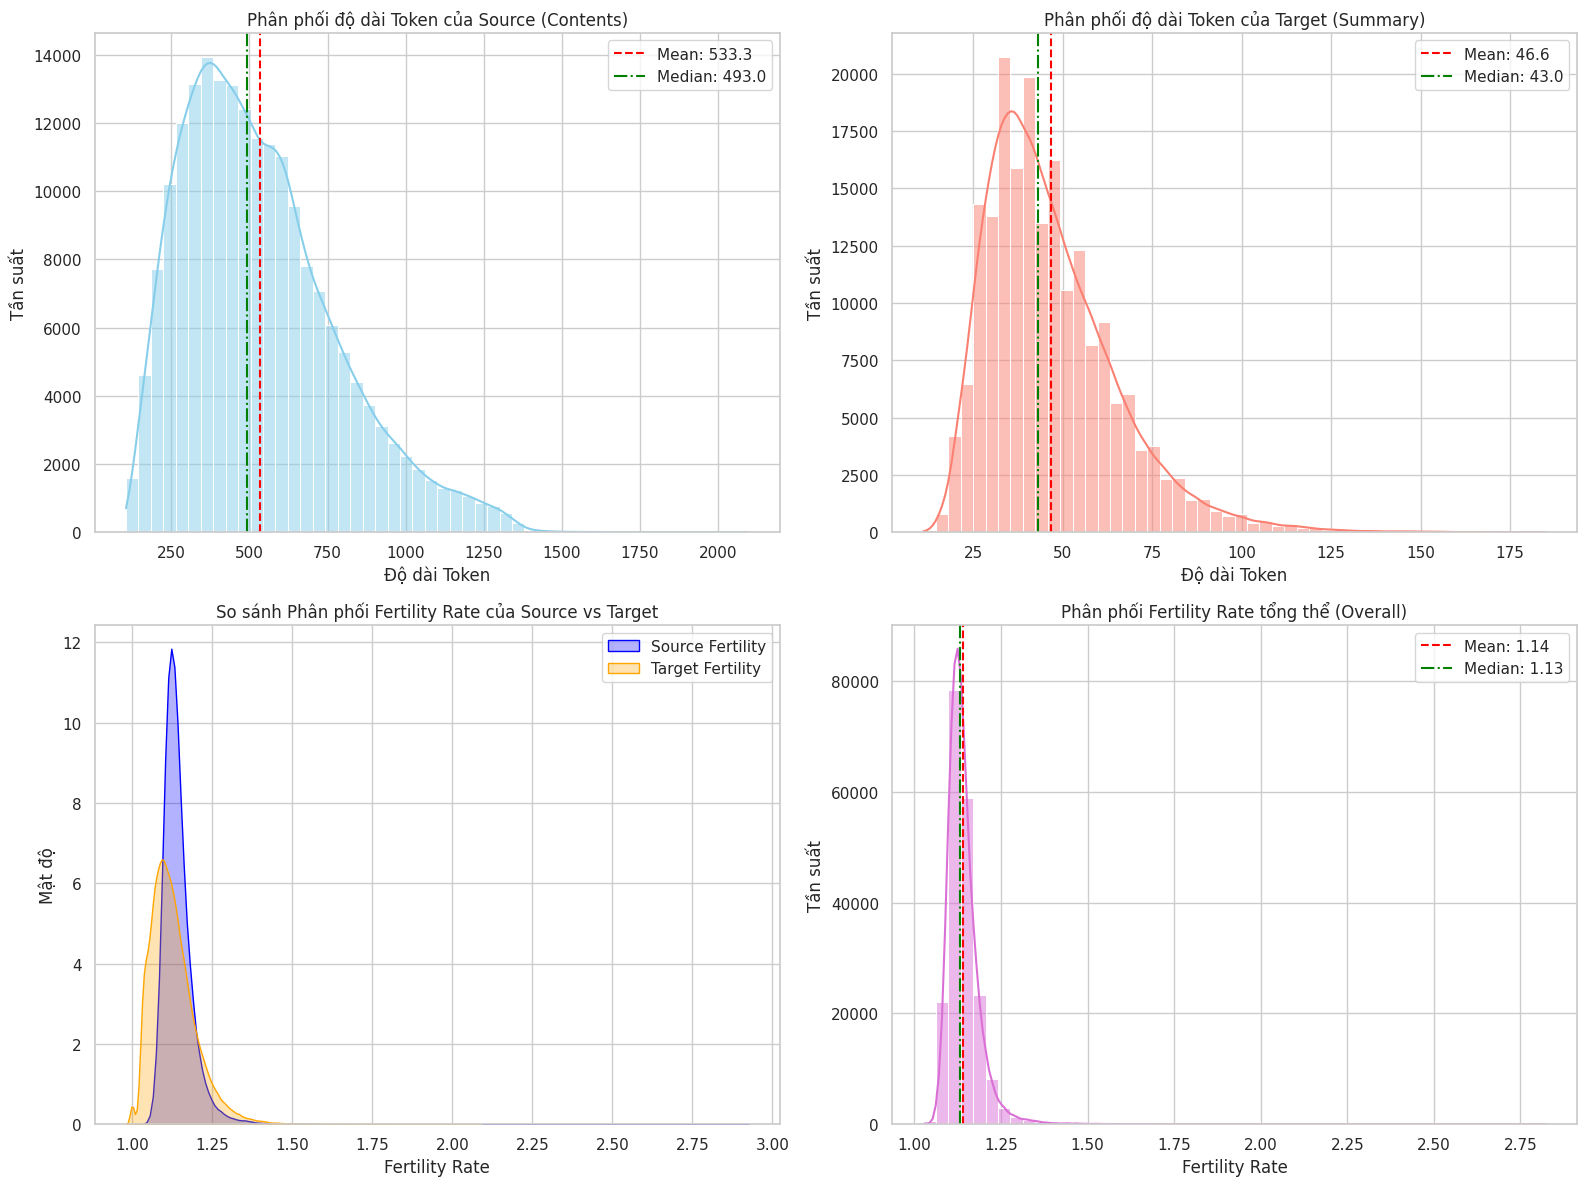

Đã lưu hình ảnh trực quan hóa ra file 'tokenizer_distributions.png'


In [6]:
if 'source_token_lens' in locals():
    # Cấu hình subplot 2x2
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Phân phối độ dài token của Source (Contents)
    sns.histplot(source_token_lens, bins=50, kde=True, ax=axes[0, 0], color="skyblue")
    axes[0, 0].axvline(src_mean, color="red", linestyle="--", label=f"Mean: {src_mean:.1f}")
    axes[0, 0].axvline(src_median, color="green", linestyle="-.", label=f"Median: {src_median:.1f}")
    axes[0, 0].set_title("Phân phối độ dài Token của Source (Contents)")
    axes[0, 0].set_xlabel("Độ dài Token")
    axes[0, 0].set_ylabel("Tần suất")
    axes[0, 0].legend()
    
    # 2. Phân phối độ dài token của Target (Summary)
    sns.histplot(target_token_lens, bins=50, kde=True, ax=axes[0, 1], color="salmon")
    axes[0, 1].axvline(tgt_mean, color="red", linestyle="--", label=f"Mean: {tgt_mean:.1f}")
    axes[0, 1].axvline(tgt_median, color="green", linestyle="-.", label=f"Median: {tgt_median:.1f}")
    axes[0, 1].set_title("Phân phối độ dài Token của Target (Summary)")
    axes[0, 1].set_xlabel("Độ dài Token")
    axes[0, 1].set_ylabel("Tần suất")
    axes[0, 1].legend()
    
    # 3. Phân phối Fertility Rate của Source và Target
    sns.kdeplot(source_fertilities, fill=True, label="Source Fertility", ax=axes[1, 0], color="blue", alpha=0.3)
    sns.kdeplot(target_fertilities, fill=True, label="Target Fertility", ax=axes[1, 0], color="orange", alpha=0.3)
    axes[1, 0].set_title("So sánh Phân phối Fertility Rate của Source vs Target")
    axes[1, 0].set_xlabel("Fertility Rate")
    axes[1, 0].set_ylabel("Mật độ")
    axes[1, 0].legend()
    
    # 4. Phân phối Fertility Rate tổng thể
    sns.histplot(overall_fertilities, bins=50, kde=True, ax=axes[1, 1], color="orchid")
    axes[1, 1].axvline(overall_fert_mean, color="red", linestyle="--", label=f"Mean: {overall_fert_mean:.2f}")
    axes[1, 1].axvline(overall_fert_median, color="green", linestyle="-.", label=f"Median: {overall_fert_median:.2f}")
    axes[1, 1].set_title("Phân phối Fertility Rate tổng thể (Overall)")
    axes[1, 1].set_xlabel("Fertility Rate")
    axes[1, 1].set_ylabel("Tần suất")
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.savefig("tokenizer_distributions.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Đã lưu hình ảnh trực quan hóa ra file 'tokenizer_distributions.png'")

In [9]:
    # Format hiển thị 2 chữ số thập phân cho Pandas
    pd.set_option('display.float_format', lambda x: '%.2f' % x)
    display(df_stats)
    print("=" * 75)
    
    # 5. Tính toán tỉ lệ bị truncate (Truncation Rate) với max_source_length = 768 và max_target_length = 96
    max_src_len = 768
    max_tgt_len = 96
    
    src_truncated = sum(1 for l in source_token_lens if l > max_src_len)
    tgt_truncated = sum(1 for l in target_token_lens if l > max_tgt_len)
    either_truncated = sum(1 for sl, tl in zip(source_token_lens, target_token_lens) if sl > max_src_len or tl > max_tgt_len)
    
    src_trunc_rate = (src_truncated / len(pairs)) * 100
    tgt_trunc_rate = (tgt_truncated / len(pairs)) * 100
    overall_trunc_rate = (either_truncated / len(pairs)) * 100
    
    print("\n" + "=" * 75)
    print("                PHÂN TÍCH TỶ LỆ TRUNCATE (RÒ RỈ THÔNG TIN)")
    print("=" * 75)
    print(f" Cấu hình độ dài tối đa: Max Source Length = {max_src_len} | Max Target Length = {max_tgt_len}")
    print(f" Số mẫu bị truncate ở Source (Contents > {max_src_len}): {src_truncated:,} ({src_trunc_rate:.4f}%)")
    print(f" Số mẫu bị truncate ở Target (Summary > {max_tgt_len}):  {tgt_truncated:,} ({tgt_trunc_rate:.4f}%)")
    print(f" Tổng số mẫu bị truncate (Source hoặc Target):           {either_truncated:,} ({overall_trunc_rate:.4f}%)")
    print("=" * 75)

,Chỉ số (Metric),Trung bình (Mean),Trung vị (Median),75% Percentile,90% Percentile,95% Percentile
0,Source Token Length (Contents),533.32,493.00,675.00,878.00,1016.00
1,Target Token Length (Summary),46.61,43.00,56.00,71.00,81.00
2,Overall Fertility Rate (Cả cặp),1.14,1.13,NaN,NaN,1.22
3,Source Fertility Rate (Contents),1.14,1.13,NaN,NaN,1.23
4,Target Fertility Rate (Summary),1.13,1.12,NaN,NaN,1.26



                PHÂN TÍCH TỶ LỆ TRUNCATE (RÒ RỈ THÔNG TIN)
 Cấu hình độ dài tối đa: Max Source Length = 768 | Max Target Length = 96
 Số mẫu bị truncate ở Source (Contents > 768): 32,935 (16.6692%)
 Số mẫu bị truncate ở Target (Summary > 96):  3,479 (1.7608%)
 Tổng số mẫu bị truncate (Source hoặc Target):           34,363 (17.3919%)
